In [6]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
from libpysal import graph
from sklearn import cluster
import contextily as cx
import matplotlib.pyplot as plt

chicago = gpd.read_file(
    "https://martinfleischmann.net/sds/clustering/data/chicago_influenza_1918.geojson"
)

chicago.head()

,geography_code,gross_acres,illit,unemployed_pct,ho_pct,agecat1,agecat2,agecat3,agecat4,agecat5,agecat6,agecat7,influenza,geometry
0,G17003100388,80.0,182,0.359360,0.024000,69,244,223,286,238,1486,577,29,"POLYGON ((358405.051 570342.347, 358371.811 57..."
1,G17003100197,79.3,592,0.318684,0.021246,138,643,470,617,374,1811,742,30,"POLYGON ((356903.353 580393.561, 356895.319 58..."
2,G17003100085,48.6,1,0.320418,0.049630,16,87,72,113,132,1152,721,8,"POLYGON ((358851.219 581708.993, 358792.352 58..."
3,G17003100472,100.2,165,0.352627,0.064782,145,705,457,548,385,1685,564,4,"POLYGON ((365743.731 564074.974, 365643.916 56..."
4,G17003100229,50.2,35,0.401565,0.031713,33,144,127,172,164,1154,603,10,"POLYGON ((353913.877 578415.37, 353914.804 578..."


<Axes: >

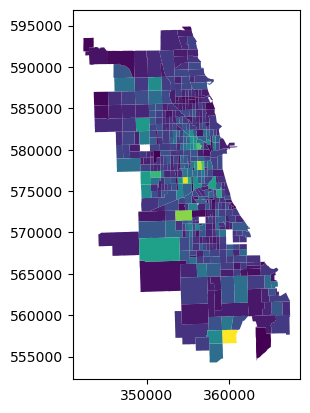

In [27]:
chicago.plot("influenza")

In [20]:
from sklearn import preprocessing

demographics = [col for col in chicago.columns if col not in ["geography_code", "geometry", "influenza"]]
chicago[demographics] = preprocessing.robust_scale(chicago[demographics])

In [21]:
chicago[demographics]

,gross_acres,illit,unemployed_pct,ho_pct,agecat1,agecat2,agecat3,agecat4,agecat5,agecat6,agecat7
0,-0.194708,0.465558,0.121762,-0.577117,-0.145658,-0.430586,-0.320059,-0.367526,-0.419623,-0.304649,-0.397324
1,-0.201697,2.413302,-0.701498,-0.629427,0.627451,0.434924,0.408555,0.358749,-0.009057,-0.143917,-0.205352
2,-0.508238,-0.394299,-0.666397,-0.090373,-0.739496,-0.771150,-0.765487,-0.747120,-0.739623,-0.469832,-0.229785
3,0.006990,0.384798,-0.014511,0.197380,0.705882,0.569414,0.370206,0.207351,0.024151,-0.206231,-0.412449
4,-0.492262,-0.232779,0.975963,-0.430631,-0.549020,-0.647505,-0.603245,-0.617663,-0.643019,-0.468843,-0.367074
...,...,...,...,...,...,...,...,...,...,...,...
491,-0.469296,0.650831,-0.563510,-0.575811,-0.201681,-0.131236,-0.054572,0.016456,0.045283,-0.377844,-0.446190
492,-0.004993,-0.247031,-0.026836,-0.270315,-0.257703,-0.241866,-0.243363,-0.262205,-0.012075,0.071217,0.443863
493,-0.011982,-0.232779,-0.441904,-0.149835,-0.459384,-0.519523,-0.452802,-0.567197,-0.742642,-0.699802,-0.612565
494,-0.262606,2.631829,-0.996667,-0.737246,0.235294,0.092191,0.184366,0.031816,-0.304906,-0.319486,-0.298429


In [24]:
# Clustering

# Elbow method
elbow_inertias = {}

for k in range(2, 15):
    kmeans = cluster.KMeans(n_clusters=k, random_state=42)
    kmeans.fit(chicago[demographics])
    elbow_inertias[k] = kmeans.inertia_

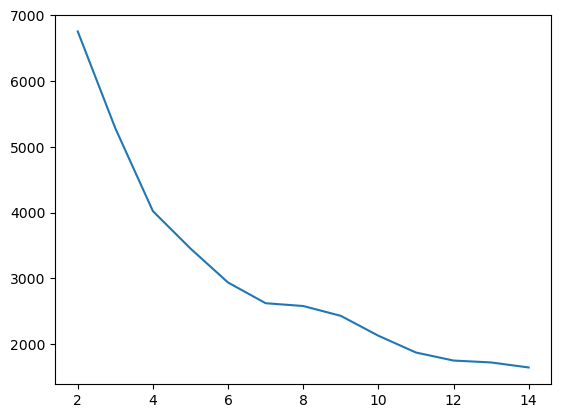

In [26]:
_ = pd.Series(elbow_inertias).plot()

It seems that the gradient of the elbow lower it's gradient at k=11 using the elbow method

In [78]:
kmeans10 = cluster.KMeans(n_clusters=10, random_state=42)
kmeans10.fit(chicago[demographics])

chicago["kmeans10"] = kmeans10.labels_

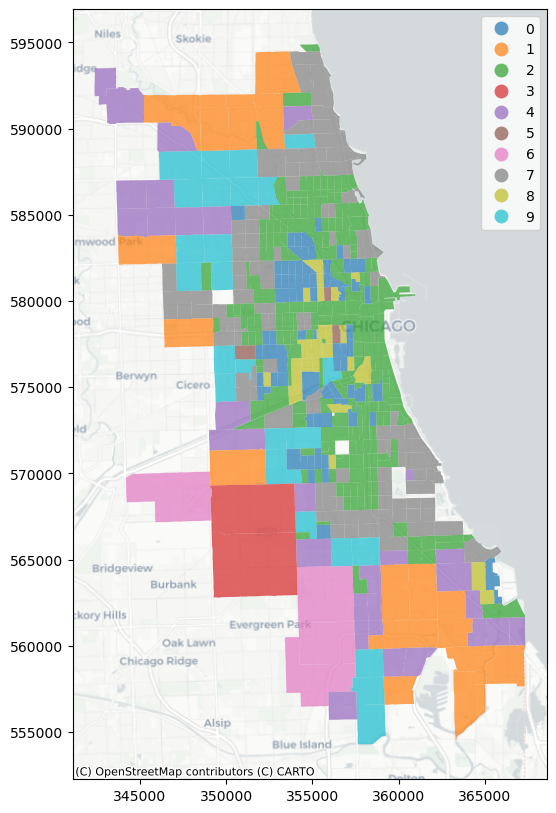

In [79]:
fig, ax = plt.subplots(figsize=(20, 10))
chicago.plot("kmeans10", ax=ax, categorical=True, legend=True, alpha=0.7)
cx.add_basemap(
    ax=ax,
    crs=chicago.crs,
    source=cx.providers.CartoDB.Positron
)

Exploring both cluster of 7 and 11 it seems that the clustering follow a concentric pattern from the main city center and out. Particularly noticable is cluster 8 which deviates from the norm and spreads out along the river?

In [80]:
# Spatial lag features and re find k
queen = graph.Graph.build_contiguity(chicago)
queen_row = queen.transform("R")
for col in demographics:
    chicago[col + "_lag"] = queen_row.lag(chicago[col])

demo_lag = [col + "_lag" for col in demographics]

In [81]:
chicago.head()

,geography_code,gross_acres,illit,unemployed_pct,ho_pct,agecat1,agecat2,agecat3,agecat4,agecat5,agecat6,agecat7,influenza,geometry,kmeans11,gross_acres_lag,illit_lag,unemployed_pct_lag,ho_pct_lag,agecat1_lag,agecat2_lag,agecat3_lag,agecat4_lag,agecat5_lag,agecat6_lag,agecat7_lag,kmeans7,kmeans_10_lagged,kmeans10
0,G17003100388,-0.194708,0.465558,0.121762,-0.577117,-0.145658,-0.430586,-0.320059,-0.367526,-0.419623,-0.304649,-0.397324,29,"POLYGON ((358405.051 570342.347, 358371.811 57...",7,-0.222000,0.101346,-0.244871,-0.410286,-0.110177,-0.235719,-0.176008,-0.240263,-0.187673,-0.044923,-0.049641,2,2,2
1,G17003100197,-0.201697,2.413302,-0.701498,-0.629427,0.627451,0.434924,0.408555,0.358749,-0.009057,-0.143917,-0.205352,30,"POLYGON ((356903.353 580393.561, 356895.319 58...",0,0.049925,1.695962,-1.869829,-0.734419,0.215686,0.319957,0.174779,-0.055403,-0.363774,-0.213773,-0.325480,0,0,0
2,G17003100085,-0.508238,-0.394299,-0.666397,-0.090373,-0.739496,-0.771150,-0.765487,-0.747120,-0.739623,-0.469832,-0.229785,8,"POLYGON ((358851.219 581708.993, 358792.352 58...",7,-0.106840,-0.178939,-1.225704,-0.647774,-0.160598,-0.218727,-0.211898,-0.132017,0.254591,1.116716,1.308319,2,2,2
3,G17003100472,0.006990,0.384798,-0.014511,0.197380,0.705882,0.569414,0.370206,0.207351,0.024151,-0.206231,-0.412449,4,"POLYGON ((365743.731 564074.974, 365643.916 56...",0,1.723082,1.852732,0.152951,0.529837,1.549953,1.411063,1.245329,0.932163,0.739623,0.404880,0.238317,0,0,0
4,G17003100229,-0.492262,-0.232779,0.975963,-0.430631,-0.549020,-0.647505,-0.603245,-0.617663,-0.643019,-0.468843,-0.367074,10,"POLYGON ((353913.877 578415.37, 353914.804 578...",7,-0.223665,0.118765,-0.418232,-0.320397,-0.159664,-0.255965,-0.149705,-0.142074,-0.091321,-0.118200,0.049738,2,2,2


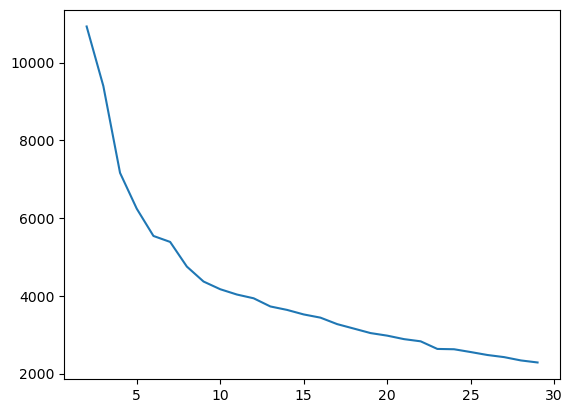

In [82]:
chicago_spatial = demographics+demo_lag

demo_lag_inertias = {}

for k in range(2, 30):
    kmeans = cluster.KMeans(n_clusters=k, random_state=42)
    kmeans.fit(chicago[chicago_spatial])
    demo_lag_inertias[k] = kmeans.inertia_

_ = pd.Series(demo_lag_inertias).plot()

In [83]:
kmeans10_lag = cluster.KMeans(n_clusters=10, random_state=42)
kmeans10_lag.fit(chicago[chicago_spatial])
chicago["kmeans_10_lagged"] = kmeans10_lag.labels_

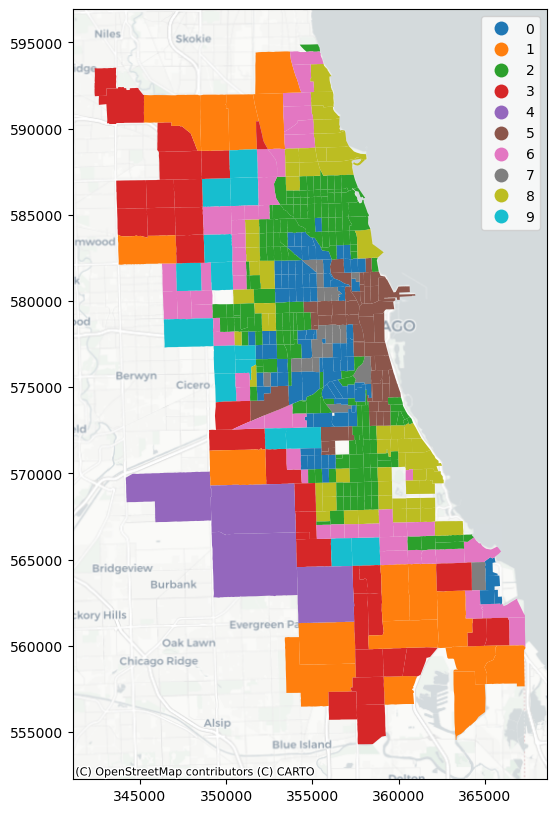

In [84]:
fix, ax = plt.subplots(figsize=(20, 10))
chicago.plot("kmeans_10_lagged", ax=ax, categorical=True, legend=True)
cx.add_basemap(
    ax=ax,
    crs=chicago.crs,
    source="CartoDB Positron"
)


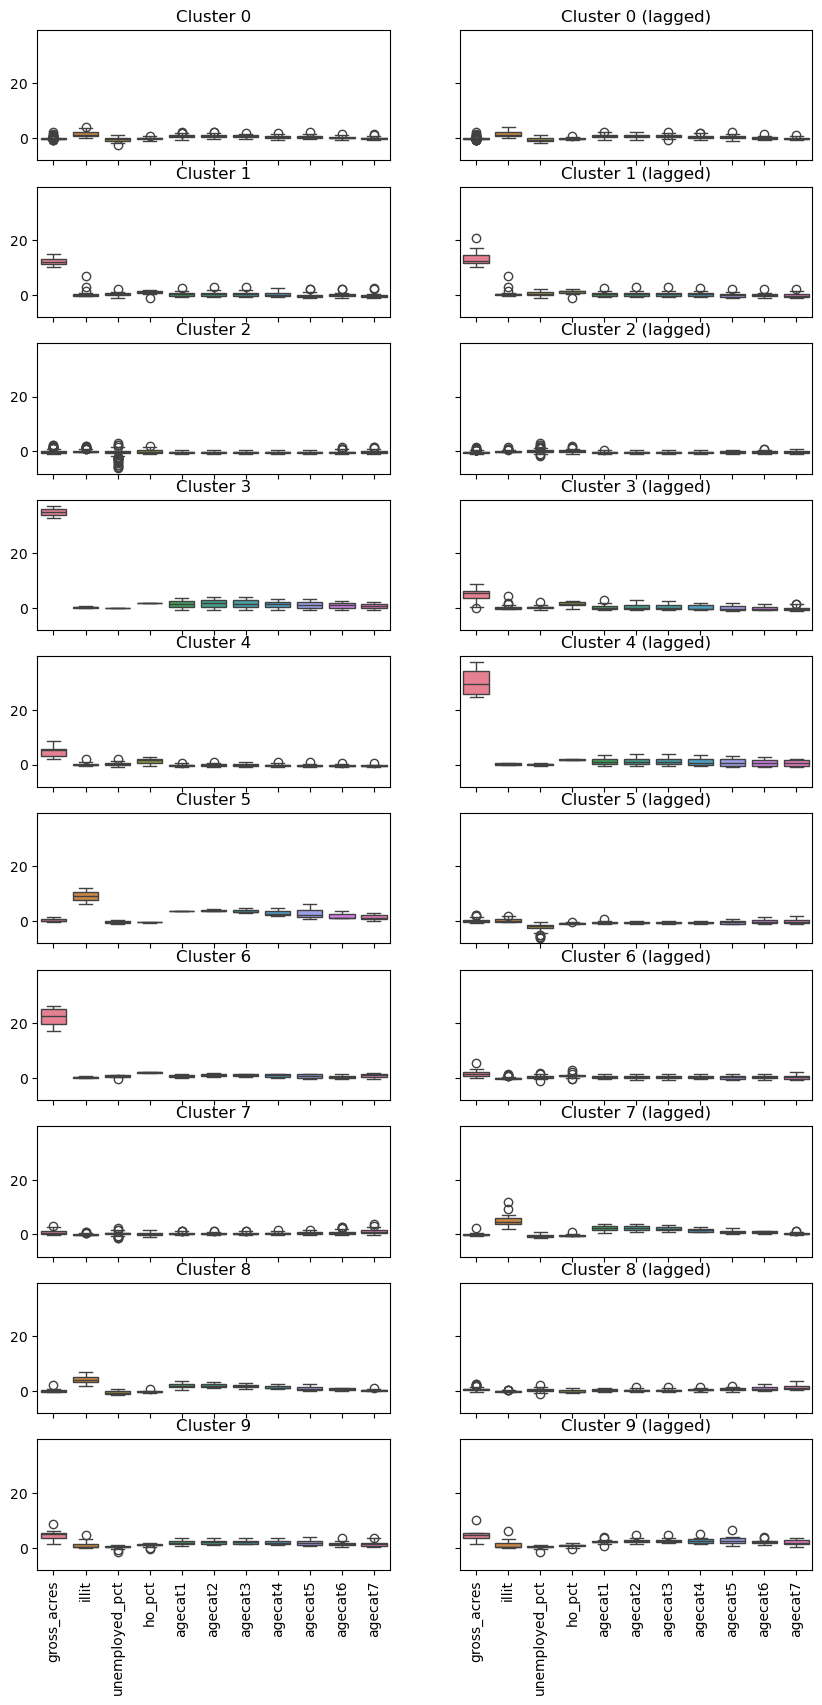

In [87]:
# Comparing spatial lag cluster with original results with both k=10

fig, axes = plt.subplots(10, 2, figsize = (10, 20), sharey=True, sharex=True)

for k in range(10):
    cluster_data = chicago.loc[chicago["kmeans10"] == k, demographics]
    cluster_lagged = chicago.loc[chicago["kmeans_10_lagged"] == k, demographics]

    sns.boxplot(data=cluster_data, ax=axes[k, 0])
    axes[k, 0].set_title(f'Cluster {k}')
    axes[k, 0].tick_params(axis='x', rotation=90)

    sns.boxplot(data=cluster_lagged, ax=axes[k, 1])
    axes[k, 1].set_title(f'Cluster {k} (lagged)')
    axes[k, 1].tick_params(axis='x', rotation=90)

Visual interpretation of the lag suggests that while most variables have not seen significant deviace between non-lagged and lagged clustering. Variable gross_acres seems to be the varying factor for several clusters, namely in custer 3, 4, and 6.

Clusters 3, 4, and 6 are all in the peripheral regions of the city of chicago. For cluster 3 the contribuition to lagged cluster is much less than un-lagged cluster, but for 4, and 6 they are much more contributing.

Other anomaly is the slight increase in controbution of variable ilit for cluster 7 which are just within the periperial area and sandwiched between the core and outer clusters.

In [96]:
# Regionalisation using AgglomerativeClustering
agg10 = cluster.AgglomerativeClustering(n_clusters=10, connectivity=queen.sparse)
agg10.fit(chicago[demographics])

lagged_agg10 = cluster.AgglomerativeClustering(n_clusters=10, connectivity=queen.sparse)
lagged_agg10.fit(chicago[chicago_spatial])

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",10
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.","<Compressed S...pe (496, 496)>"
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [97]:
chicago["agg_10"] = agg10.labels_
chicago["agg_10_lagged"] = lagged_agg10.labels_

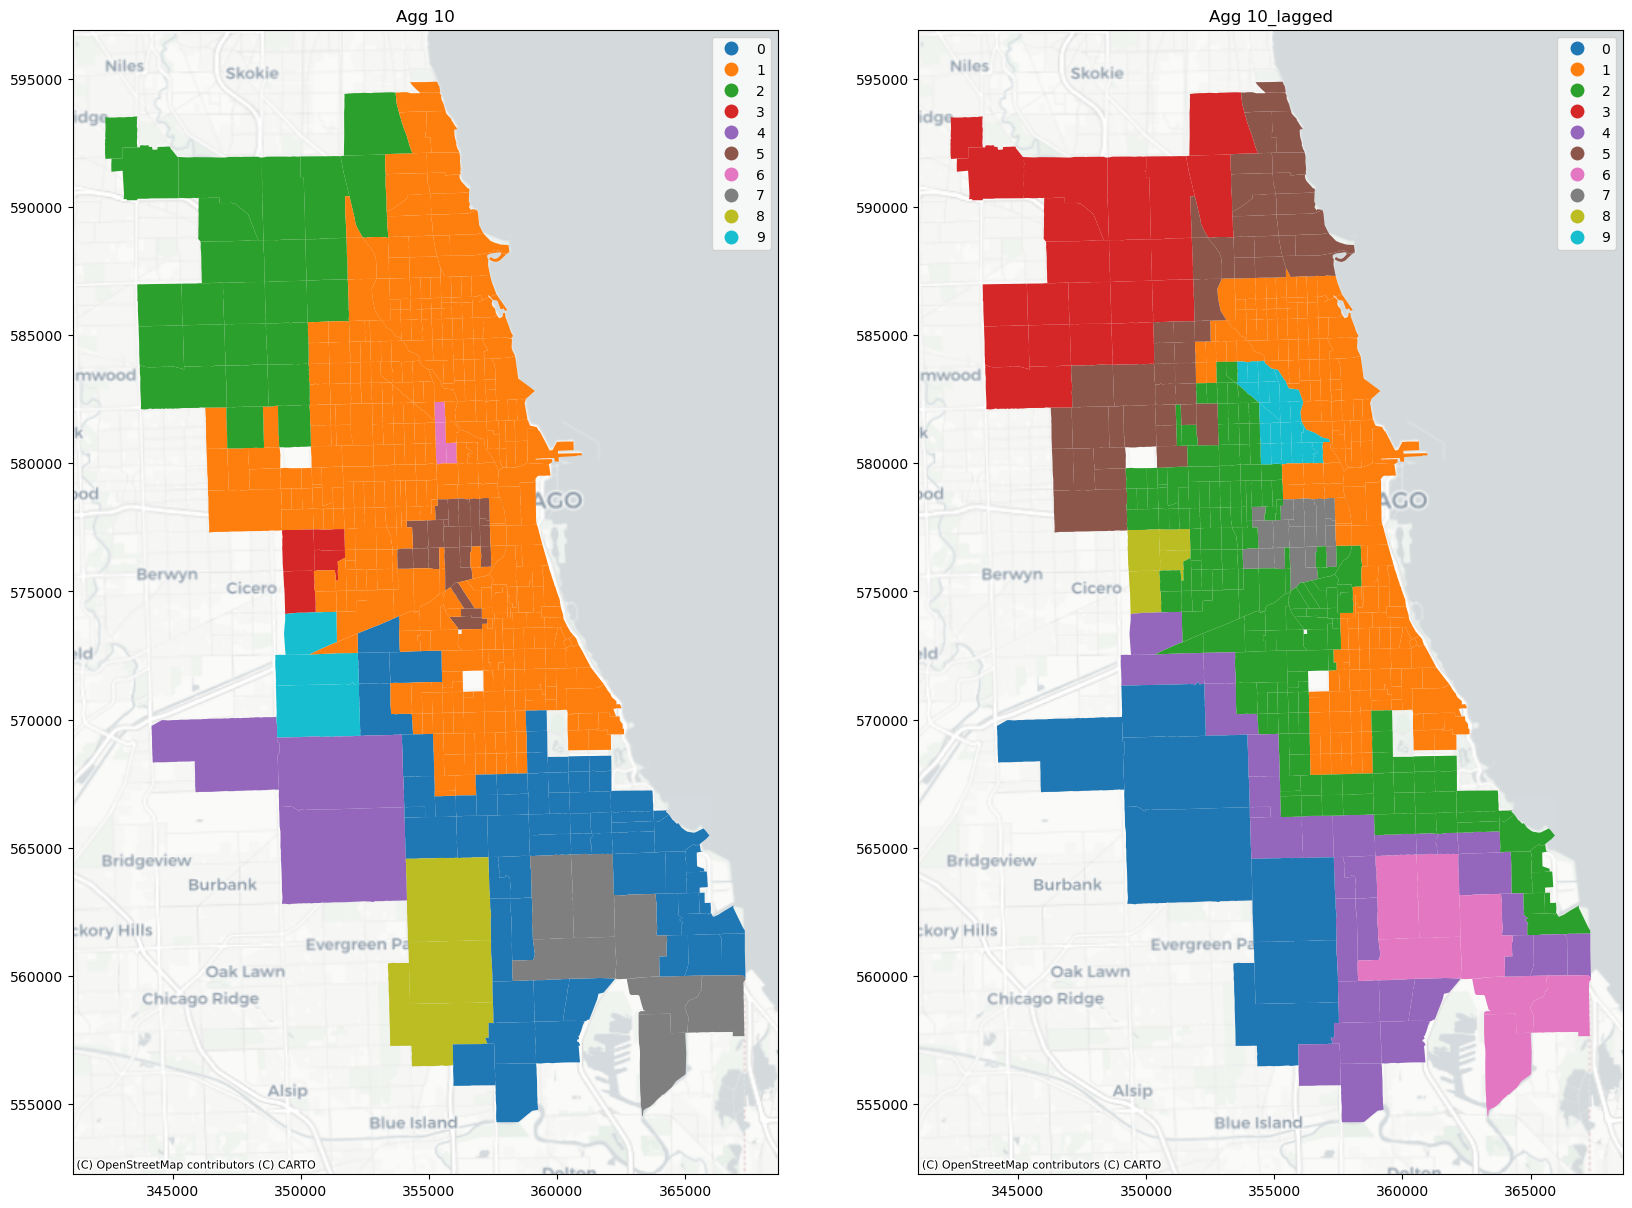

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(20, 20))
chicago.plot("agg_10", categorical=True, legend=True, ax=ax[0])
cx.add_basemap(
    ax=ax[0],
    crs=chicago.crs,
    source="CartoDB Positron"
)

chicago.plot("agg_10_lagged", categorical=True, legend=True, ax=ax[1])
cx.add_basemap(
    ax=ax[1],
    crs=chicago.crs,
    source="CartoDB Positron"
)

ax[0].title.set_text("Agg 10")
ax[1].title.set_text("Agg 10_lagged")

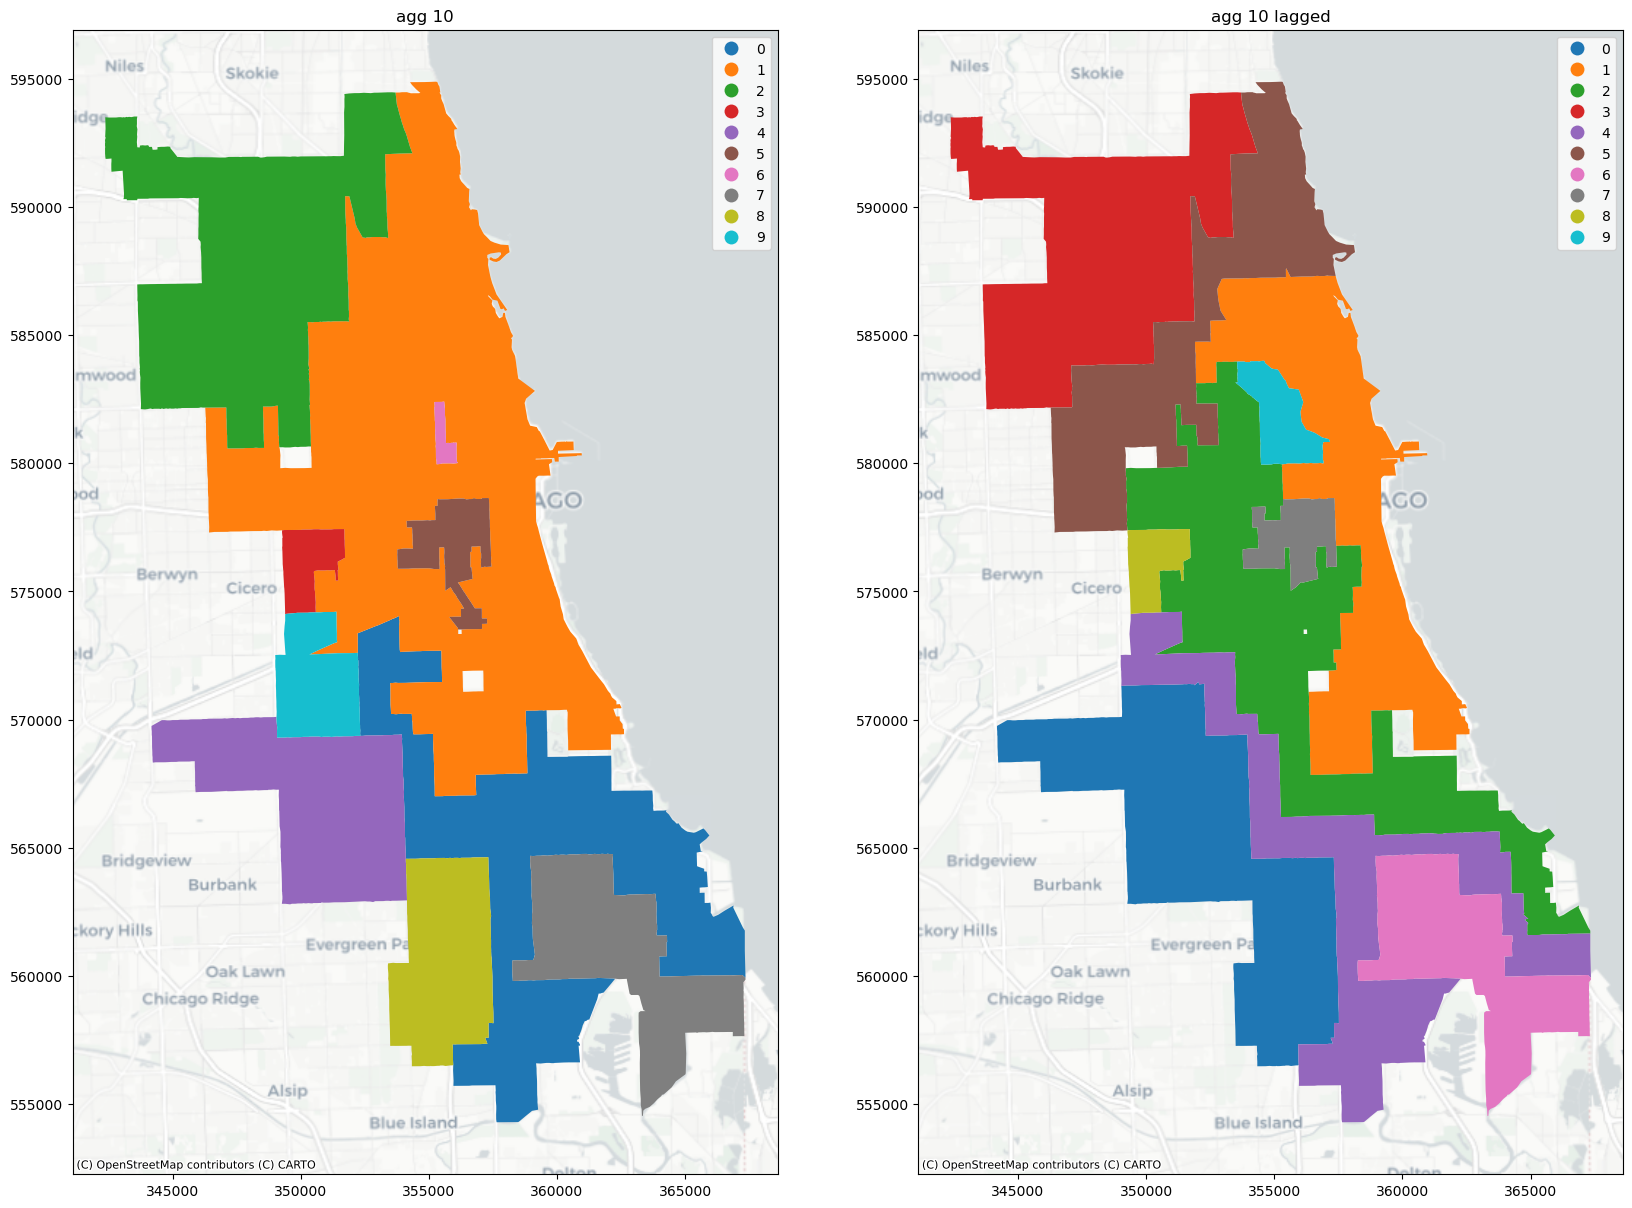

In [105]:
chicago_agg_regions = chicago[["agg_10", "geometry"]].dissolve("agg_10").reset_index()
chicago_agg_lag_regions = chicago[["agg_10_lagged", "geometry"]].dissolve("agg_10_lagged").reset_index()

fig, ax = plt.subplots(1, 2, figsize=(20, 20))
chicago_agg_regions.plot("agg_10", categorical=True, legend=True, ax=ax[0])
cx.add_basemap(
    ax=ax[0],
    crs=chicago.crs,
    source="CartoDB Positron"
)
chicago_agg_lag_regions.plot("agg_10_lagged", categorical=True, legend=True, ax=ax[1])
cx.add_basemap(
    ax=ax[1],
    crs=chicago.crs,
    source="CartoDB Positron"
)

ax[0].title.set_text("agg 10")
ax[1].title.set_text("agg 10 lagged")

I think the agglomerative are easier to understand than interpretate than the k-means results. Of course the usage depends and is based on the use case. While Kmeans provide a more granular approach and the lagged model provide significantly better spatial consideration than the non spatial kmeans. The agglomerative clustering have long stretches of clusters for lagged compare to non-log which does not follow a concentric urban model. Perhaps the double encoding of spatial feature in the agglomerative lag model causes over fitting of the cluster.

Based on these basic observation, the lagged Kmeans and non lagged agglomerative model might be better suited for further analysis.